<a href="https://colab.research.google.com/github/Ahmednsh/ML-projects/blob/main/Severity_Prediction/severity_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.ensemble import RandomForestClassifier


In [2]:

project_path = "https://raw.githubusercontent.com/Ahmednsh/ML-projects/main/Severity_Prediction/attacks.csv"
data = pd.read_csv(project_path)

# Basic data description
print("Shape of the data:", data.shape)
print("Number of features:", data.shape[1])
print("Number of samples:", data.shape[0])
print(data.describe())  # Basic statistics

Shape of the data: (200, 16)
Number of features: 16
Number of samples: 200
         severity   source_port   dest_port    latitude   longitude
count  200.000000    200.000000  200.000000  200.000000  200.000000
mean    73.550000  35891.750000  179.090000    7.284591   -3.225928
std     17.403792  18694.835934  187.899101   37.930130  102.732934
min     35.000000   1645.000000    0.000000  -59.457105 -177.524535
25%     68.000000  18785.500000   22.000000  -24.155372  -88.541172
50%     77.000000  37868.500000   80.000000    9.192783    5.592923
75%     88.000000  52008.250000  443.000000   40.554390   85.069437
max    100.000000  65188.000000  443.000000   69.876364  178.964754


In [ ]:
data["severity"].value_counts()

,count
severity,
68,44
88,39
40,24
83,18
100,18
77,17
78,14
70,13
73,7


In [ ]:
data

,TimeGenerated,attack_type,severity,source_ip,dest_ip,source_port,dest_port,protocol,ports_scanned,username,password,http_path,payload,latitude,longitude,note
0,2025-10-31T07:52:00.983303Z,web_xss,78,107.39.156.167,65.111.159.52,49389,443,TCP,0,webadmin167,P@ssw0rd,/checkout?q=test,<script>alert(1)</script>,-48.314798,84.974467,XSS attempt
1,2025-10-27T02:47:23.983303Z,ssh_bruteforce,70,234.213.171.93,36.41.16.170,34280,22,TCP,0,root,pass,/login,ssh_attempt,-5.898837,-112.601230,multiple failures
2,2025-10-11T02:39:30.983303Z,web_abnormal_request,68,228.20.83.243,239.108.153.223,53955,443,HTTP,0,guest243,P@ssw0rd,/weird2,/big-request?size=999999999,-11.501946,-144.754735,Abnormal request pattern
3,2025-10-13T20:42:25.983303Z,ssh_bruteforce,77,213.251.230.141,33.11.81.232,17822,22,TCP,0,root,1234,/login,ssh_attempt,-48.422167,121.816641,failed login
4,2025-10-21T00:22:00.983303Z,web_file_upload,83,234.135.157.183,55.115.159.215,35000,443,TCP,0,svc183,Welcome1!,/upload,/upload.php?file=malware.php,9.326348,101.004140,Suspicious file upload
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2025-10-16T16:16:56.983303Z,web_xss,73,11.28.60.94,243.224.221.153,53306,80,HTTP,0,webadmin94,Passw0rd!,/admin?q=test,<img src=x onerror=alert(1)>,-42.339659,-84.620250,XSS attempt
196,2025-10-21T18:48:01.983303Z,web_abnormal_request,68,37.197.136.239,68.81.181.60,41666,80,TCP,0,svc239,S3cure#70,/weird86,/%2e%2e/%2e%2e/..,53.662917,-135.730356,Abnormal request pattern
197,2025-10-02T14:54:15.983303Z,web_auth_bypass,88,64.165.216.176,142.40.215.124,46730,443,HTTP,0,user176,S3cure#63,/admin?role=admin,/admin?role=admin,69.876364,26.857539,Auth bypass pattern
198,2025-10-04T05:34:16.983303Z,web_xss,78,245.107.137.162,169.218.87.232,4437,443,HTTP,0,webadmin162,letmein2024,/checkout?q=test,"""><script>alert(1)</script>",69.581950,-172.105123,XSS attempt


In [ ]:
data.columns

Index(['TimeGenerated', 'attack_type', 'severity', 'source_ip', 'dest_ip',
       'source_port', 'dest_port', 'protocol', 'ports_scanned', 'username',
       'password', 'http_path', 'payload', 'latitude', 'longitude', 'note'],
      dtype='object')

In [ ]:
catogorical = data.dtypes[data.dtypes == object].index.tolist()
print(catogorical)

['TimeGenerated', 'attack_type', 'source_ip', 'dest_ip', 'protocol', 'ports_scanned', 'username', 'password', 'http_path', 'payload', 'note']


In [ ]:
numerical = data.dtypes[data.dtypes != object].index.tolist()
print(numerical)

['severity', 'source_port', 'dest_port', 'latitude', 'longitude']


In [ ]:
data['attack_type-numeric'] = pd.factorize(data['attack_type'])[0]
data['source_ip-numeric'] = pd.factorize(data['source_ip'])[0]
data['ports_scanned-numeric'] = pd.factorize(data['ports_scanned'])[0]
data['protocol-numeric'] = pd.factorize(data['protocol'])[0]
data['payload-numeric'] = pd.factorize(data['payload'])[0]
data['note-numeric'] = pd.factorize(data['note'])[0]
data['TimeGenerated-numeric'] = pd.factorize(data['TimeGenerated'])[0]
data['dest_ip-numeric'] = pd.factorize(data['dest_ip'])[0]
data['username-numeric'] = pd.factorize(data['username'])[0]
data['password-numeric'] = pd.factorize(data['password'])[0]
data['http_path-numeric'] = pd.factorize(data['http_path'])[0]

In [ ]:
columns_to_remove = ['TimeGenerated', 'attack_type', 'source_ip', 'dest_ip', 'protocol', 'ports_scanned', 'username', 'password', 'http_path', 'payload', 'note']
new_data = data.drop(columns_to_remove, axis=1, inplace=True)

In [ ]:
print(data)

     severity  source_port  dest_port   latitude   longitude  \
0          78        49389        443 -48.314798   84.974467   
1          70        34280         22  -5.898837 -112.601230   
2          68        53955        443 -11.501946 -144.754735   
3          77        17822         22 -48.422167  121.816641   
4          83        35000        443   9.326348  101.004140   
..        ...          ...        ...        ...         ...   
195        73        53306         80 -42.339659  -84.620250   
196        68        41666         80  53.662917 -135.730356   
197        88        46730        443  69.876364   26.857539   
198        78         4437        443  69.581950 -172.105123   
199        77        52481         22 -33.375650   57.143315   

     attack_type-numeric  source_ip-numeric  ports_scanned-numeric  \
0                      0                  0                      0   
1                      1                  1                      0   
2                    

In [ ]:
data.columns

Index(['severity', 'source_port', 'dest_port', 'latitude', 'longitude',
       'attack_type-numeric', 'source_ip-numeric', 'ports_scanned-numeric',
       'protocol-numeric', 'payload-numeric', 'note-numeric',
       'TimeGenerated-numeric', 'dest_ip-numeric', 'username-numeric',
       'password-numeric', 'http_path-numeric'],
      dtype='object')

In [ ]:
data.isna().any()

,0
severity,False
source_port,False
dest_port,False
latitude,False
longitude,False
attack_type-numeric,False
source_ip-numeric,False
ports_scanned-numeric,False
protocol-numeric,False
payload-numeric,False


In [ ]:
data.duplicated().any()

np.False_

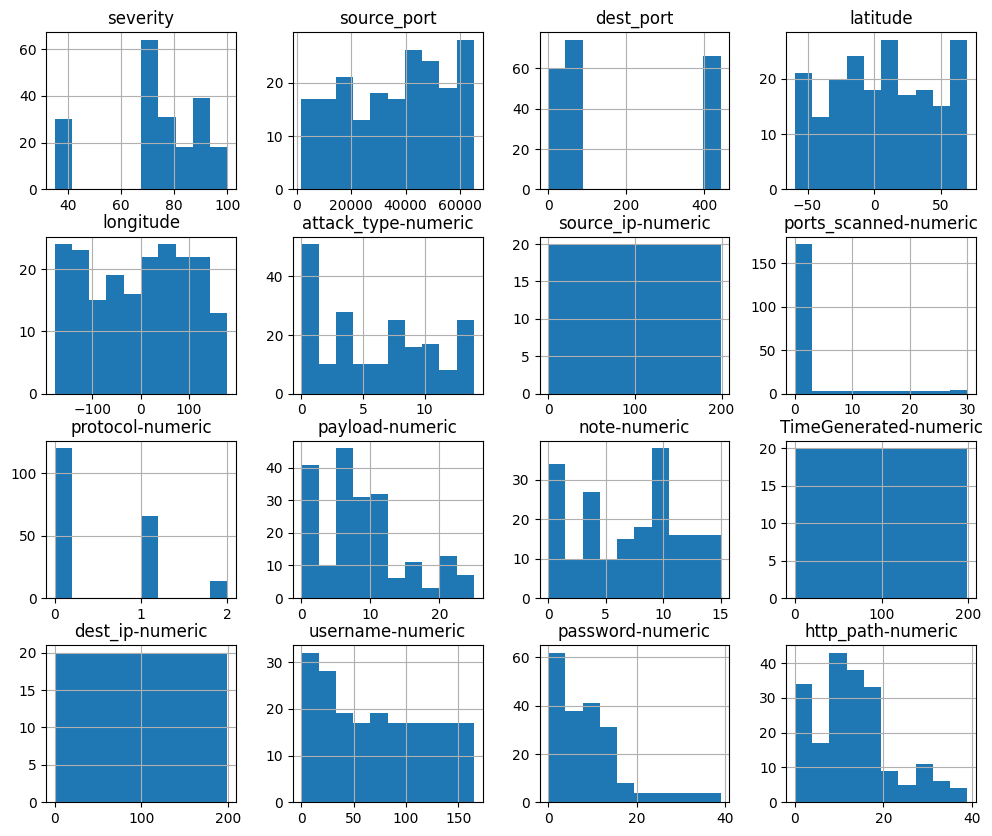

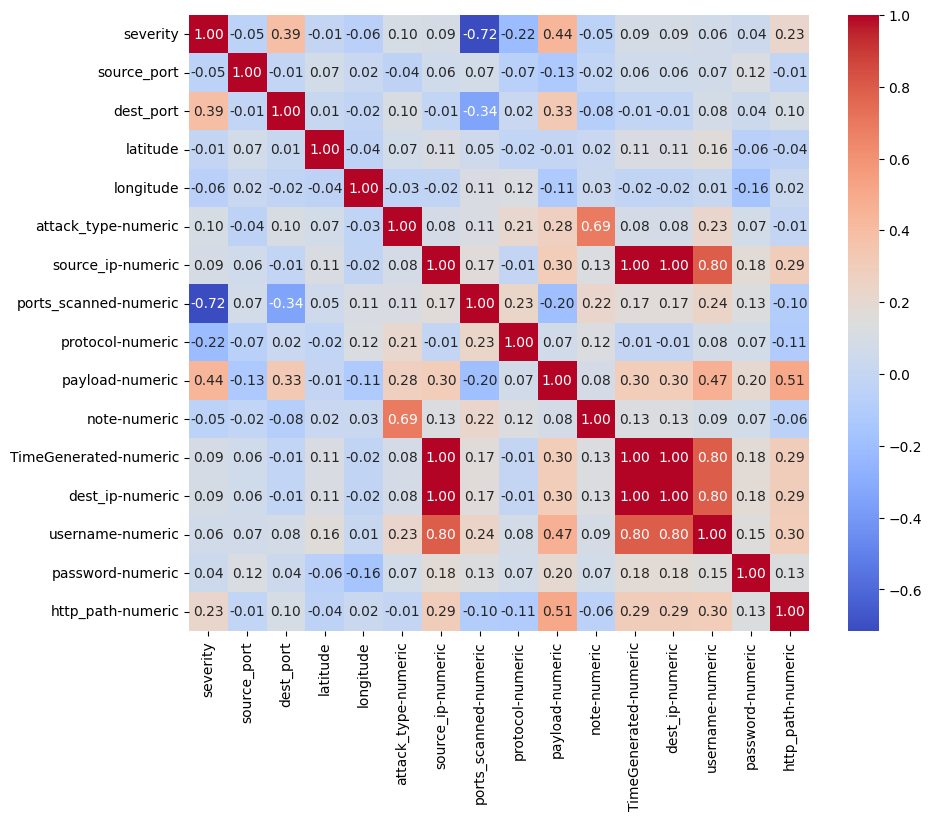

In [ ]:
# Histograms for each feature
data[['severity', 'source_port', 'dest_port', 'latitude', 'longitude',
       'attack_type-numeric', 'source_ip-numeric', 'ports_scanned-numeric',
       'protocol-numeric', 'payload-numeric', 'note-numeric',
       'TimeGenerated-numeric', 'dest_ip-numeric', 'username-numeric',
       'password-numeric', 'http_path-numeric']].hist(figsize=(12, 10))
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()


In [ ]:
data_changed = data[['severity', 'dest_port',
       'attack_type-numeric', 'ports_scanned-numeric',
       'payload-numeric',
        'http_path-numeric', 'source_ip-numeric', 'protocol-numeric', 'note-numeric']]

In [ ]:
data_changed.columns

Index(['severity', 'dest_port', 'attack_type-numeric', 'ports_scanned-numeric',
       'payload-numeric', 'http_path-numeric', 'source_ip-numeric',
       'protocol-numeric', 'note-numeric'],
      dtype='object')

In [ ]:
data_changed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   severity               200 non-null    int64
 1   dest_port              200 non-null    int64
 2   attack_type-numeric    200 non-null    int64
 3   ports_scanned-numeric  200 non-null    int64
 4   payload-numeric        200 non-null    int64
 5   http_path-numeric      200 non-null    int64
 6   source_ip-numeric      200 non-null    int64
 7   protocol-numeric       200 non-null    int64
 8   note-numeric           200 non-null    int64
dtypes: int64(9)
memory usage: 14.2 KB


In [ ]:
# Using Min-Max Scaler
scaler = MinMaxScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(data_changed), columns=data_changed.columns)
data_scaled

,severity,dest_port,attack_type-numeric,ports_scanned-numeric,payload-numeric,http_path-numeric,source_ip-numeric,protocol-numeric,note-numeric
0,0.661538,1.000000,0.000000,0.0,0.00,0.000000,0.000000,0.0,0.000000
1,0.538462,0.049661,0.071429,0.0,0.04,0.025641,0.005025,0.0,0.066667
2,0.507692,1.000000,0.142857,0.0,0.08,0.051282,0.010050,0.5,0.133333
3,0.646154,0.049661,0.071429,0.0,0.04,0.025641,0.015075,0.0,0.200000
4,0.738462,1.000000,0.214286,0.0,0.12,0.076923,0.020101,0.0,0.266667
...,...,...,...,...,...,...,...,...,...
195,0.584615,0.180587,0.000000,0.0,0.40,0.333333,0.979899,0.5,0.000000
196,0.507692,0.180587,0.142857,0.0,0.68,1.000000,0.984925,0.0,0.133333
197,0.815385,1.000000,1.000000,0.0,0.32,0.256410,0.989950,0.5,0.600000
198,0.661538,1.000000,0.000000,0.0,0.88,0.000000,0.994975,0.5,0.000000


In [ ]:
model = RandomForestClassifier()
# Assuming 'label' is the target variable
X = data_scaled.drop('severity', axis=1)
y = data_changed['severity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
# Train and evaluate Random Forest classifier (only)
model.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Random Forest Accuracy: {acc:.2f}, F1 Score: {f1:.2f}")

# The confusion matrix and plotting for Random Forest is already handled in the next cell (vxdm8TkHmUZq)
# so we don't need to duplicate it here.

Random Forest Accuracy: 0.93, F1 Score: 0.92


Random Forest Accuracy: 0.93, F1 Score: 0.92


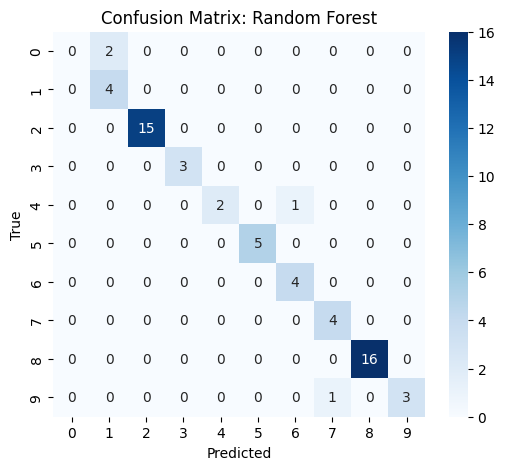

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Assuming rf_clf (RandomForestClassifier) and the data (X_train, X_test, y_train, y_test) are already defined

# Train and evaluate Random Forest classifier
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Random Forest Accuracy: {acc:.2f}, F1 Score: {f1:.2f}")

# Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.title('Confusion Matrix: Random Forest')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Remove the code for comparing classifiers as only Random Forest is used now.
# plt.figure(figsize=(10, 6))
# sns.barplot(x=[acc], y=["Random Forest"], palette='Blues_d', hue=["Random Forest"], legend=False)
# plt.title('Comparing Classifiers')
# plt.xlabel('Accuracy')
# plt.ylabel('Classifier')
# plt.show()

In [ ]:
import joblib

joblib.dump(model, '/content/drive/MyDrive/Colab Notebooks/models/random_forest_model.pkl')

['/content/drive/MyDrive/Colab Notebooks/models/random_forest_model.pkl']

In [ ]:
import joblib

model = joblib.load('/content/drive/MyDrive/Colab Notebooks/models/random_forest_model.pkl')

In [ ]:
from pickle import INT
import pandas as pd # Import pandas

print("enter the following data")

dest_port = float(input("dest_port: "))
# Get attack_type as a string
attack_type_str = input("attack_type: ")
ports_scanned_str = input("ports_scanned: ") # Read as string
payload_str = input("payload: ") # Read as string
http_path_str = input("http_path: ") # Read as string
source_ip_str = input("source_ip: ") # Read as string
protocol_str = input("protocol: ") # Read as string
note_str = input("note: ") # Read as string

# Reload the original data to access original categorical columns for factorization
original_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/attacks.csv")

# Use the same factorization as before to convert attack_type string to numeric
# Make sure 'data' DataFrame is available in the environment with the original 'attack_type' column

def get_numeric_factor(input_str, original_series):
    if not input_str:
        return -1 # Return a placeholder for empty input
    unique_values = pd.factorize(original_series)[1]
    try:
        return unique_values.get_loc(input_str)
    except KeyError:
        return -1 # Return a placeholder if the input string is not found in unique values

attack_type_numeric = get_numeric_factor(attack_type_str, original_data['attack_type'])
ports_scanned_numeric = get_numeric_factor(ports_scanned_str, original_data['ports_scanned'])
payload_numeric = get_numeric_factor(payload_str, original_data['payload'])
http_path_numeric = get_numeric_factor(http_path_str, original_data['http_path'])
source_ip_numeric = get_numeric_factor(source_ip_str, original_data['source_ip'])
protocol_numeric = get_numeric_factor(protocol_str, original_data['protocol'])
note_numeric = get_numeric_factor(note_str, original_data['note'])

# Create DataFrame for the inputs - ensure column names match the training data features excluding 'severity'
user_input = pd.DataFrame([[0, dest_port, attack_type_numeric, ports_scanned_numeric, payload_numeric, http_path_numeric, source_ip_numeric, protocol_numeric, note_numeric]],
                          columns=['severity', 'dest_port', 'attack_type-numeric', 'ports_scanned-numeric', 'payload-numeric', 'http_path-numeric', 'source_ip-numeric', 'protocol-numeric', 'note-numeric'])


# Scale the user input using the same scaler used for training
# Ensure the 'scaler' object is available in the environment
if 'scaler' in locals() and scaler is not None:
    user_input_scaled = scaler.transform(user_input)
else:
    print("Error: Scaler not found. Please run the cell that trains and saves the scaler.")
    user_input_scaled = None # Set to None or handle as appropriate

# Predict the severity
if user_input_scaled is not None and 'model' in locals() and model is not None:
    # Remove the placeholder 'severity' column before prediction
    user_input_scaled = user_input_scaled[:, 1:]
    prediction = model.predict(user_input_scaled)[0]

    # Assuming 'data_changed' target_names are the unique values of 'severity'
    # If not, you might need a mapping from the numeric prediction to the original severity value
    # For this dataset, the prediction will be one of the severity values directly.
    predicted_severity = prediction

    print(f"\n Predicted Severity: {predicted_severity}")
else:
    print("Error: Model not found or input scaling failed. Please run the cell that trains and saves the model.")

enter the following data
dest_port: 2
attack_type: uh
ports_scanned: 2
payload: ij
http_path: mp
source_ip: 22
protocol: k
note: mpk

 Predicted Severity: 78


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
